# Object Detection — YOLO

## Problem Definition

Classification says "this image is a dog." Detection says "there is a dog at pixels (112, 40, 280, 210), there is a cat at (400, 180, 560, 310), and nothing else in the frame."

That one structural change — predicting **a variable number of labelled boxes** instead of one label per image — is what every autonomous system, every surveillance product, every document layout parser, and every factory vision line depends on.

* Regression head. boxes that are accurate
* Classification head. right class for each box 
* Objectness score. there is nothing to detect
* Non-maximum suppression. One prediction per real object

## Basic Concept

### Detection as dense prediction

A classifier outputs C numbers per image. A YOLO-style detector outputs `(S x S x (5 + C))` numbers per image, where S is the spatial grid size.

```mermaid
flowchart TD
    IMG["Input 416x416 RGB"] --> BB["Backbone<br/>(ResNet, DarkNet, ...)"]
    BB --> FM["Feature map<br/>(C_feat, 13, 13)"]
    FM --> HEAD["Detection head<br/>(1x1 convs)"]
    HEAD --> OUT["Output tensor<br/>(13, 13, B * (5 + C))"]
    OUT --> DEC["Decode<br/>(grid + sigmoid + exp)"]
    DEC --> NMS["Non-max suppression"]
    NMS --> RESULT["Final boxes"]

    style IMG fill:#dbeafe,stroke:#2563eb
    style HEAD fill:#fef3c7,stroke:#d97706
    style NMS fill:#fecaca,stroke:#dc2626
    style RESULT fill:#dcfce7,stroke:#16a34a
```

Each of the `S * S` grid cells predicts `B` boxes. For each box:

- 4 numbers describe geometry: `tx, ty, tw, th`.
- 1 number is the objectness score: "is there an object centred in this cell?"
- C numbers are class probabilities.

Total per cell: `B * (5 + C)`. For VOC with `S=13, B=2, C=20`, that is 50 numbers per cell.

### Why grids and anchors

The grid answers this by assigning each ground-truth box to the grid cell its centre falls in; **only that cell is responsible for that object.**

pre-define `B` prior box shapes (anchors) per cell and predict small deltas from each anchor. The model learns to **pick the right anchor and nudge it rather than regress from nothing.**

```
Anchor box priors (example for 416x416 input):

  small:   (30,  60)
  medium:  (75,  170)
  large:   (200, 380)

At each grid cell, every anchor emits (tx, ty, tw, th, obj, c_1, ..., c_C).
```

### Decoding predictions

The raw `tx, ty, tw, th` are not box coordinates; they are regression targets to be transformed before plotting:

```
centre x  = (sigmoid(tx) + cell_x) * stride
centre y  = (sigmoid(ty) + cell_y) * stride
width     = anchor_w * exp(tw)
height    = anchor_h * exp(th)
```

`sigmoid` keeps centre offsets inside the cell. `exp` lets the width scale freely from the anchor without a sign flip. `stride` scales the grid coordinates back to pixels. This decode step is the same in every YOLO version since v2.

### IoU

Detection's universal similarity metric between two boxes:

```
IoU(A, B) = area(A intersect B) / area(A union B)
```

IoU = 1 means identical; IoU = 0 means no overlap. IoU between the prediction and **the ground-truth box is what decides whether a prediction counts as a true positive** (typically IoU >= 0.5). IoU between two predictions is what NMS uses to deduplicate.

### Non-maximum suppression

A conv network trained on adjacent anchors will often **predict overlapping boxes for the same object**. NMS **keeps the highest-confidence prediction and deletes any other prediction** with IoU above a threshold.

### The loss

YOLO loss is three losses added with weights:

```
L = lambda_coord * L_box(pred, target, where obj=1)
  + lambda_obj   * L_obj(pred, 1,     where obj=1)
  + lambda_noobj * L_obj(pred, 0,     where obj=0)
  + lambda_cls   * L_cls(pred, target, where obj=1)
```

Only cells that contain an object contribute to the box-regression and classification losses. Cells without objects contribute only to the objectness loss (teaching the model to stay silent). `lambda_noobj` is **usually small (~0.5) because the vast majority of cells are empty and would otherwise dominate the total loss.**

### Dection Metrics

Accuracy does not transfer to detection. Four numbers that do:





Precision@IoU=0.5 — of the predictions counted as positives, how many are actually correct.



Recall@IoU=0.5 — of the real objects, how many did we find.



AP@0.5 — precision-recall curve area at IoU threshold 0.5; one number per class.



mAP@0.5:0.95 — average of AP over IoU thresholds 0.5, 0.55, ..., 0.95. The COCO metric; strictest and most informative.

# Build your Own

## IoU

In [7]:
import numpy as np

def box_iou(boxes_a, boxes_b):
    ax1, ay1, ax2, ay2 = boxes_a[:, 0], boxes_a[:, 1], boxes_a[:, 2], boxes_a[:, 3]
    bx1, by1, bx2, by2 = boxes_b[:, 0], boxes_b[:, 1], boxes_b[:, 2], boxes_b[:, 3]

    inter_x1 = np.maximum(ax1[:, None], bx1[None, :])
    inter_y1 = np.maximum(ay1[:, None], by1[None, :])
    inter_x2 = np.minimum(ax2[:, None], bx2[None, :])
    inter_y2 = np.minimum(ay2[:, None], by2[None, :])

    inter_w = np.clip(inter_x2 - inter_x1, 0, None)
    inter_h = np.clip(inter_y2 - inter_y1, 0, None)
    inter = inter_w * inter_h

    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    union = area_a[:, None] + area_b[None, :] - inter
    return inter / np.clip(union, 1e-8, None)

test_boxes_a = np.array([[10, 10, 20, 20], [30, 30, 40, 40]])
test_boxes_b = np.array([[15, 15, 25, 25], [35, 35, 45, 45]])

print(box_iou(test_boxes_a, test_boxes_b))


[[0.14285714 0.        ]
 [0.         0.14285714]]


## Non-max suppression

In [8]:
def nms(boxes, scores, iou_threshold=0.45):
    order = np.argsort(-scores)
    keep = []
    while len(order) > 0:
        i = order[0]
        keep.append(i)
        if len(order) == 1:
            break
        rest = order[1:]
        ious = box_iou(boxes[[i]], boxes[rest])[0]
        order = rest[ious <= iou_threshold]
    return np.array(keep, dtype=np.int64)

## Box encoding and decoding

In [9]:
def encode(box_xyxy, cell_x, cell_y, stride, anchor_wh):
    """
    Encode box coordinates to YOLO format.
    box_xyxy: [x1, y1, x2, y2]
    cell_x: cell x coordinate
    cell_y: cell y coordinate
    stride: stride of the grid
    anchor_wh: width and height of the anchor
    """
    x1, y1, x2, y2 = box_xyxy
    cx = 0.5 * (x1 + x2)
    cy = 0.5 * (y1 + y2)
    w = x2 - x1
    h = y2 - y1

    tx = cx / stride - cell_x
    ty = cy / stride - cell_y
    tw = np.log(w / anchor_wh[0] + 1e-8)
    th = np.log(h / anchor_wh[1] + 1e-8)
    return np.array([tx, ty, tw, th])

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def decode(tx_ty_tw_th, cell_x, cell_y, stride, anchor_wh):
    """
    Decode YOLO format to box coordinates.
    """
    tx, ty, tw, th = tx_ty_tw_th
    # tx, ty are logits from (-inf, inf)
    # use sigmoid to convert to (0, 1)
    cx = (sigmoid(tx) + cell_x) * stride
    cy = (sigmoid(ty) + cell_y) * stride
    w = np.exp(tw) * anchor_wh[0]
    h = np.exp(th) * anchor_wh[1]
    return np.array([cx - 0.5 * w, cy - 0.5 * h, cx + 0.5 * w, cy + 0.5 * h])


## YOLO Head

Reshaping to (B, S, S, num_anchros, 5 + C)

The last dimension holds [tx, ty, tw, th, obj, cls_0, ..., cls_{C-1}].

In [10]:
import torch
import torch.nn as nn

class YOLOHead(nn.Module):
    def __init__(self, in_c, num_anchors, num_classes):
        super().__init__()
        self.num_anchors = num_anchors
        self.num_classes = num_classes
        self.conv = nn.Conv2d(in_c, num_anchors * (5 + num_classes), kernel_size=1)

    def forward(self, x):
        n, _, h, w = x.shape
        y = self.conv(x)
        y = y.view(n, self.num_anchors, 5 + self.num_classes, h, w)
        y = y.permute(0, 3, 4, 1, 2).contiguous()
        return y

In [11]:
def yolo_loss(pred, target, has_obj, lambda_coord=5.0, lambda_obj=1.0,
    lambda_noobj=0.5, lambda_cls=1.0):
    has_obj_t = torch.from_numpy(has_obj).bool()
    target_t = torch.from_numpy(target).float()

    # Box-Regression Loss: only on cell with objects
    box_pred = pred[..., :4][has_obj_t]
    box_true = target_t[..., :4][has_obj_t]
    loss_box = torch.nn.functional.mse_loss(box_pred, box_true, reduction="sum")

    # Objectness Loss
    obj_pred = pred[..., 4]
    obj_true = target_t[..., 4]
    loss_obj_pos = torch.nn.functional.binary_cross_entropy_with_logits(
        obj_pred[has_obj_t], obj_true[has_obj_t], reduction="sum"
    )
    loss_obj_neg = torch.nn.functional.binary_cross_entropy_with_logits(
        obj_pred[~has_obj_t], obj_true[~has_obj_t], reduction="sum"
    )

    # Classification Loss
    cls_pred = pred[..., 5:][has_obj_t]
    cls_true = target_t[..., 5:][has_obj_t]
    loss_cls = torch.nn.functional.binary_cross_entropy_with_logits(
        cls_pred, cls_true, reduction="sum"
    )

    total = (lambda_coord * loss_box) + (lambda_obj * loss_obj_pos) + (lambda_noobj * loss_obj_neg) + (lambda_cls * loss_cls)
    return total

    
    

## Exisiting Implement in Torch

In [14]:
import torch
import torch.nn as nn
# {检测器}_{骨干网络}_{Neck/特征结构}_{版本}
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


def run_demo(model, title):
    model.eval()
    with torch.no_grad():
        pred = model([torch.randn(3, 400, 600)])[0]
    scores = pred["scores"]
    print(title)
    print(f"  keys: {pred.keys()}")
    print(
        f"  boxes/scores/labels: {tuple(pred['boxes'].shape)} / "
        f"{tuple(scores.shape)} / {tuple(pred['labels'].shape)}"
    )
    if len(scores):
        print(f"  score min/max: {scores.min():.3f} / {scores.max():.3f}")
    print(
        f"  score_thresh={model.roi_heads.score_thresh}, "
        f"detections_per_img={model.roi_heads.detections_per_img}"
    )
    return pred


# 1) Pretrained COCO head — random noise usually yields few boxes
model = fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features  # 1024
run_demo(model, "pretrained DEFAULT")

# 2) Swap head for fine-tuning (2 foreground classes + background).
#    New head is randomly initialized: softmax scores often ≈ 1.0 on junk
#    proposals, so nearly everything passes score_thresh=0.05 and hits the
#    detections_per_img=100 cap. N is variable, not a fixed output dim.
num_classes = 3
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
run_demo(model, "FastRCNNPredictor (untrained)")

# 3) Custom head — same contract: (scores[N, C], deltas[N, C*4])
class MyBoxPredictor(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_channels, 512),
            nn.ReLU(inplace=True),
        )
        self.cls_score = nn.Linear(512, num_classes)
        self.bbox_pred = nn.Linear(512, num_classes * 4)

    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = self.fc(x)
        return self.cls_score(x), self.bbox_pred(x)


model = fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = MyBoxPredictor(in_features, num_classes=3)
pred = run_demo(model, "MyBoxPredictor (untrained)")

# 100 means "hit the post-NMS cap", not a broken tensor shape.
# Untrained head on noise is not meaningful; fine-tune before trusting boxes.
print(
    "counts at thresh 0.05 / 0.3 / 0.5:",
    int((pred["scores"] > 0.05).sum()),
    int((pred["scores"] > 0.3).sum()),
    int((pred["scores"] > 0.5).sum()),
)

dict_keys(['boxes', 'labels', 'scores'])
boxes:  torch.Size([4, 4])
scores: torch.Size([4])
labels: torch.Size([4])
dict_keys(['boxes', 'labels', 'scores'])
boxes:  torch.Size([100, 4])
scores: torch.Size([100])
labels: torch.Size([100])
dict_keys(['boxes', 'labels', 'scores'])
boxes:  torch.Size([100, 4])
scores: torch.Size([100])
labels: torch.Size([100])


## Fine-tune head: color patches on a flat background

Synthetic single-class detector (`num_classes = 2` = background + patch). Freeze backbone and RPN; train `roi_heads.box_head` + `box_predictor`.

device: mps
trainable tensors: 18
epoch 1/10  loss=0.5017
epoch 2/10  loss=0.1900
epoch 3/10  loss=0.1669
epoch 4/10  loss=0.1608
epoch 5/10  loss=0.1705
epoch 6/10  loss=0.1261
epoch 7/10  loss=0.1821
epoch 8/10  loss=0.2010
epoch 9/10  loss=0.1704
epoch 10/10  loss=0.1247
pred boxes above 0.5: 3 / 11


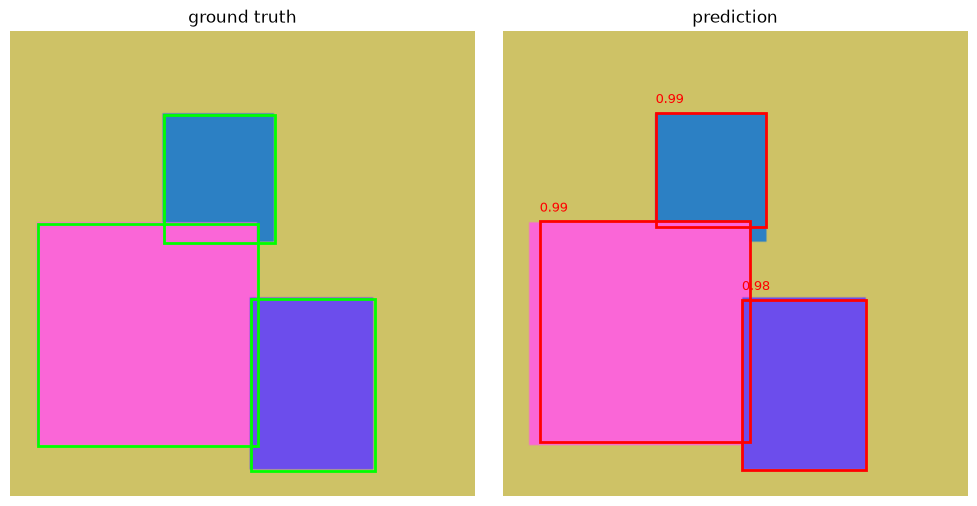

In [17]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


class ColorPatchDataset(Dataset):
    """Solid background + 1–3 contrasting rectangles. Label 1 = patch."""

    def __init__(self, n=64, size=192, max_patches=3, seed=0):
        self.n = n
        self.size = size
        self.max_patches = max_patches
        self.rng = random.Random(seed)

    def __len__(self):
        return self.n

    def _rand_color(self, avoid=None, min_delta=80):
        while True:
            c = torch.tensor([self.rng.randint(0, 255) for _ in range(3)], dtype=torch.float32)
            if avoid is None or (c - avoid).abs().sum().item() >= min_delta:
                return c

    def __getitem__(self, idx):
        h = w = self.size
        bg = self._rand_color()
        img = bg.view(3, 1, 1).expand(3, h, w).contiguous().clone()
        boxes, labels = [], []
        for _ in range(self.rng.randint(1, self.max_patches)):
            bw = self.rng.randint(24, 96)
            bh = self.rng.randint(24, 96)
            x1 = self.rng.randint(0, w - bw)
            y1 = self.rng.randint(0, h - bh)
            x2, y2 = x1 + bw, y1 + bh
            color = self._rand_color(avoid=bg)
            img[:, y1:y2, x1:x2] = color.view(3, 1, 1)
            boxes.append([x1, y1, x2, y2])
            labels.append(1)
        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
        }
        return img / 255.0, target


def collate_fn(batch):
    return tuple(zip(*batch))


def build_patch_detector(num_classes=2):
    model = fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    for p in model.parameters():
        p.requires_grad = False
    # freeze backbone + RPN; train RoI head (box_head + predictor)
    for p in model.roi_heads.box_head.parameters():
        p.requires_grad = True
    for p in model.roi_heads.box_predictor.parameters():
        p.requires_grad = True
    return model


def train_patch_detector(epochs=5, steps_per_epoch=8, batch_size=2, lr=5e-4):
    device = torch.device("mps")
    print("device:", device)
    ds = ColorPatchDataset(n=steps_per_epoch * batch_size, size=192, seed=0)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    model = build_patch_detector().to(device)
    model.train()
    params = [p for p in model.parameters() if p.requires_grad]
    print("trainable tensors:", len(params))
    opt = torch.optim.Adam(params, lr=lr)

    for epoch in range(epochs):
        total = 0.0
        n_batches = 0
        for images, targets in loader:
            images = [im.to(device) for im in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()
            n_batches += 1
        print(f"epoch {epoch + 1}/{epochs}  loss={total / max(n_batches, 1):.4f}")
    return model, device


def show_pred(model, device, score_thresh=0.5, seed=99):
    ds = ColorPatchDataset(n=1, size=192, seed=seed)
    img, target = ds[0]
    model.eval()
    with torch.no_grad():
        pred = model([img.to(device)])[0]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for ax, title in zip(axes, ["ground truth", "prediction"]):
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(title)
        ax.axis("off")

    for box in target["boxes"]:
        x1, y1, x2, y2 = box.tolist()
        axes[0].add_patch(
            patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2)
        )

    keep = pred["scores"] >= score_thresh
    for box, score in zip(pred["boxes"][keep].cpu(), pred["scores"][keep].cpu()):
        x1, y1, x2, y2 = box.tolist()
        axes[1].add_patch(
            patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=2)
        )
        axes[1].text(x1, max(y1 - 4, 0), f"{score:.2f}", color="red", fontsize=9)
    print(f"pred boxes above {score_thresh}: {int(keep.sum())} / {len(pred['scores'])}")
    plt.tight_layout()
    plt.show()


model, device = train_patch_detector(epochs=10)
show_pred(model, device)